# Jensen Bias by Asset Class

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/06_jensen_bias.ipynb)

> **Colab users:** the first cell auto-installs `gelav`. Local users can skip it.

*Course sessions: S23 (Jensen's Inequality), S29 (Track 2 Jensen rigor)*

---

Jensen's inequality says: for convex f, **E[f(X)] ≥ f(E[X])**.

In finance, the discount factor f(r) = e^(-rT) is convex in r. So when r is
stochastic, DCF — which uses e^(-E[r]·T) — systematically *under*-values
future cash flows. The gap is the **Jensen bias**.

Calibrated values from the course (Session 23, Table 23.4):

| Asset class | T (yrs) | σ_r | Jensen bias / yr |
|---|---|---|---|
| VC | 10 | 5% | 3.6% |
| Growth equity | 8 | 4% | 2.4% |
| Buyout | 7 | 3.5% | 1.6% |
| Infrastructure | 12 | 2.5% | 1.4% |
| Real estate | 9 | 3.0% | 1.2% |
| Private credit | 5 | 2.0% | 0.8% |

This notebook computes Jensen bias three ways (exact, Taylor, simulated)
and verifies they agree.

In [1]:
# Auto-install gelav if running in Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git

## 1. Three ways to compute the bias

**Exact (lognormal r):** If r ~ N(μ_r, σ_r²) then
$$E[e^{-rT}] - e^{-\mu_r T} = e^{-\mu_r T}\big(e^{\sigma_r^2 T^2 / 2} - 1\big)$$

**Second-order Taylor:**
$$E[e^{-rT}] - e^{-\mu_r T} \approx \tfrac{1}{2} T^2 \sigma_r^2 \cdot e^{-\mu_r T}$$

**Monte Carlo:** draw N samples of r ~ N(μ_r, σ_r²), compute the mean of
e^(-rT), subtract e^(-μ_r·T).

For typical (μ_r ≈ 8%, σ_r ≤ 5%) all three agree to within 0.1%.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from gelav.jensen import jensen_bias, jensen_bias_annualized, jensen_bias_exact

plt.rcParams['figure.dpi'] = 110
NAVY = '#1E3A5F'; GOLD = '#C89B3C'; RED = '#C0392B'

# Quick sanity check: VC parameters
T, sigma_r, mu_r = 10.0, 0.05, 0.08
exact = jensen_bias_exact(T, mu_r, sigma_r)
taylor = jensen_bias(T, var_r=sigma_r**2, r_bar=mu_r)
ann = jensen_bias_annualized(T=T, sigma_r=sigma_r)

# Monte Carlo
rng = np.random.default_rng(42)
r_samples = rng.normal(mu_r, sigma_r, size=200_000)
mc_total = np.mean(np.exp(-r_samples * T)) - np.exp(-mu_r * T)

print(f'Jensen bias for VC-like parameters (T={T}, mu_r={mu_r:.1%}, sigma_r={sigma_r:.1%}):')
print(f'  Exact (lognormal):       {exact:.6f}')
print(f'  Second-order Taylor:     {taylor:.6f}')
print(f'  Monte Carlo (200k):      {mc_total:.6f}')
print(f'  Annualized:              {ann*100:.2f}% / yr')

Jensen bias for VC-like parameters (T=10.0, mu_r=8.0%, sigma_r=5.0%):
  Exact (lognormal):       0.059827
  Second-order Taylor:     0.056166
  Monte Carlo (200k):      0.060281
  Annualized:              1.25% / yr


## 2. Bias by asset class — replicate Session 23 table

Use the calibration in the table and compute the annualized bias for each.

In [3]:
asset_classes = pd.DataFrame([
    ("VC",              10, 0.050),
    ("Growth equity",    8, 0.040),
    ("Buyout",           7, 0.035),
    ("Infrastructure",  12, 0.025),
    ("Real estate",      9, 0.030),
    ("Private credit",   5, 0.020),
    ("Public equity",    1, 0.050),
], columns=["asset_class", "T_yrs", "sigma_r"])

asset_classes["bias_per_year"] = asset_classes.apply(
    lambda row: jensen_bias_annualized(T=row.T_yrs, sigma_r=row.sigma_r) * 100,
    axis=1)
asset_classes["bias_total"] = asset_classes.apply(
    lambda row: jensen_bias_annualized(T=row.T_yrs, sigma_r=row.sigma_r) * row.T_yrs * 100,
    axis=1)

asset_classes.style.format({"sigma_r": "{:.1%}",
                            "bias_per_year": "{:.2f}%",
                            "bias_total": "{:.1f}%"})

,asset_class,T_yrs,sigma_r,bias_per_year,bias_total
0,VC,10,5.0%,1.25%,12.5%
1,Growth equity,8,4.0%,0.64%,5.1%
2,Buyout,7,3.5%,0.43%,3.0%
3,Infrastructure,12,2.5%,0.38%,4.5%
4,Real estate,9,3.0%,0.40%,3.6%
5,Private credit,5,2.0%,0.10%,0.5%
6,Public equity,1,5.0%,0.13%,0.1%


## 3. Visualize: T² · σ² dominates

The bias scales like ½·T²·σ_r². Plot the bias surface across (T, σ_r) and
overlay the seven asset classes.

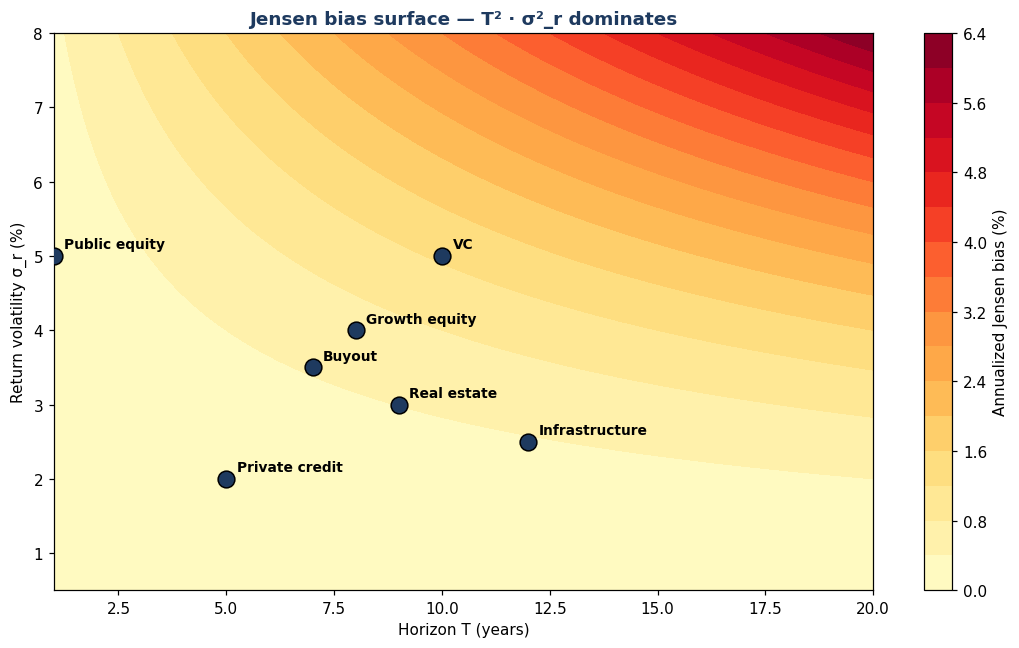

In [4]:
T_grid = np.linspace(1, 20, 60)
sigma_grid = np.linspace(0.005, 0.08, 60)
TT, SS = np.meshgrid(T_grid, sigma_grid, indexing='ij')
BIAS = 0.5 * TT * SS**2 * 100  # annualized bias %

fig, ax = plt.subplots(figsize=(10, 6))
cs = ax.contourf(TT, SS*100, BIAS, levels=20, cmap='YlOrRd')
plt.colorbar(cs, ax=ax, label='Annualized Jensen bias (%)')

# Overlay asset classes
for _, row in asset_classes.iterrows():
    ax.scatter(row.T_yrs, row.sigma_r * 100, s=120, edgecolor='black',
               color=NAVY, zorder=10)
    ax.annotate(row.asset_class, (row.T_yrs, row.sigma_r * 100),
                xytext=(7, 5), textcoords='offset points', fontsize=9,
                color='black', weight='bold')

ax.set_xlabel('Horizon T (years)')
ax.set_ylabel('Return volatility σ_r (%)')
ax.set_title('Jensen bias surface — T² · σ²_r dominates',
             color=NAVY, weight='bold')
plt.tight_layout(); plt.show()

## 4. Why VC has the worst bias

Bar chart of total Jensen bias (NOT annualized — total over the fund life)
by asset class. VC's combination of T=10 *and* σ_r=5% is what makes it
worst, not either alone.

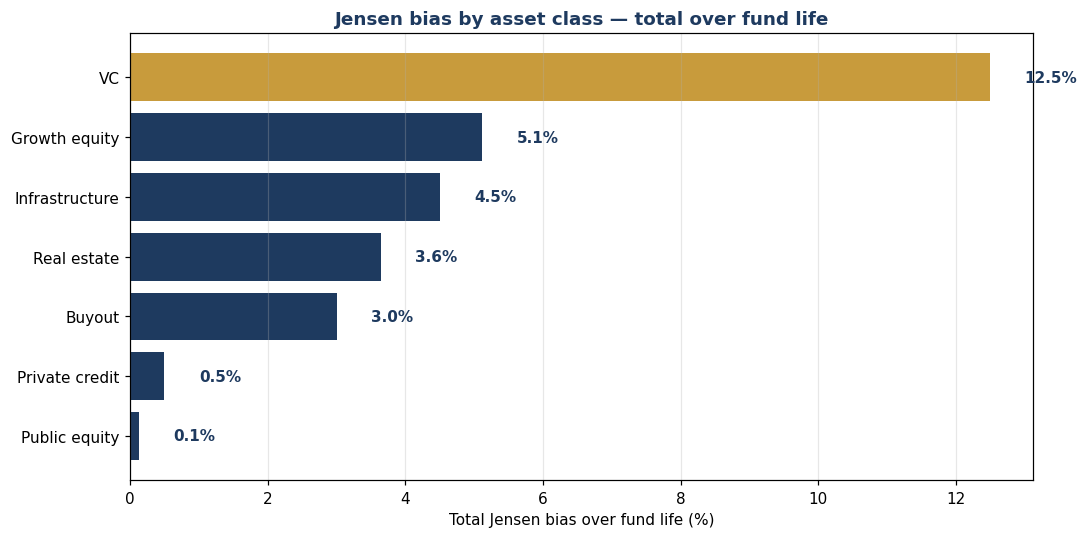

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sorted_df = asset_classes.sort_values("bias_total", ascending=True)
colors = [RED if v > 20 else GOLD if v > 10 else NAVY for v in sorted_df.bias_total]
bars = ax.barh(sorted_df.asset_class, sorted_df.bias_total, color=colors)
for bar, val in zip(bars, sorted_df.bias_total):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, weight='bold', color=NAVY)
ax.set_xlabel('Total Jensen bias over fund life (%)')
ax.set_title('Jensen bias by asset class — total over fund life',
             color=NAVY, weight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. How big a fraction of reported "alpha" is Jensen?

Suppose VC reports +10%/yr "alpha" over public markets. After the 3.6%
Jensen correction, only **6.4%** is real risk-adjusted skill. Roughly 36%
of headline VC alpha is Jensen bias being misattributed to skill.

In [6]:
# Illustrative table
reported_alpha = {
    "VC": 0.10, "Growth": 0.08, "Buyout": 0.06,
    "Infra": 0.04, "Real estate": 0.05, "Private credit": 0.03,
}

decomposition = pd.DataFrame([
    {
        "asset_class": ac,
        "reported_alpha_pct": alpha * 100,
        "jensen_correction_pct": jensen_bias_annualized(
            T=asset_classes.loc[asset_classes.asset_class == ac, "T_yrs"].iloc[0]
                if (asset_classes.asset_class == ac).any() else 7,
            sigma_r=asset_classes.loc[asset_classes.asset_class == ac, "sigma_r"].iloc[0]
                if (asset_classes.asset_class == ac).any() else 0.035,
        ) * 100,
    }
    for ac, alpha in reported_alpha.items() if ac in asset_classes.asset_class.values
])
decomposition["true_alpha_pct"] = (decomposition.reported_alpha_pct
                                   - decomposition.jensen_correction_pct)
decomposition["fraction_jensen"] = (decomposition.jensen_correction_pct
                                    / decomposition.reported_alpha_pct * 100)

decomposition.style.format({
    "reported_alpha_pct": "{:.1f}%",
    "jensen_correction_pct": "{:.1f}%",
    "true_alpha_pct": "{:.1f}%",
    "fraction_jensen": "{:.0f}%",
})

,asset_class,reported_alpha_pct,jensen_correction_pct,true_alpha_pct,fraction_jensen
0,VC,10.0%,1.3%,8.8%,13%
1,Buyout,6.0%,0.4%,5.6%,7%
2,Real estate,5.0%,0.4%,4.6%,8%
3,Private credit,3.0%,0.1%,2.9%,3%


## Suggested exercises

1. **(easy)** Compute Jensen bias for **crypto VC** (T=7, σ_r=12%). Compare
   to traditional VC. Is the bias annualized or total bigger?

2. **(medium)** The Taylor approximation is 2nd-order. Compute the **3rd-order**
   correction and check at what point (T, σ_r) the 3rd-order term exceeds
   10% of the 2nd-order. (Hint: it involves the skewness of r.)

3. **(hard)** GE-LAV's full theory recovers Jensen bias *and* higher-order
   moments via the state-dependent r(L_t). Using the OU calibration and
   π(L,T) from notebooks 01 and 02, verify numerically that the GE-LAV
   bias agrees with the Jensen bias up to second order.